# Notebook 09: Ensemble Checkpoint

This notebook serves as the final model-combination checkpoint in the holdout-validation phase. It should be read as the closing comparison before the project shifts from model exploration toward stronger validation design.


c:\Users\LENOVO\anaconda3\lib\site-packages\dask\dataframe\utils.py:13: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


09_ensemble_xgb_lgb: XGBoost + LightGBM model ensemble

1. Load data...
Train shape: (700000, 26)

2. Prepare data...
Total encoded feature count: 45
Train set: (560000, 45), Validation set: (140000, 45)

3. Load previously trained best models...
✓ XGBoost model loaded successfully
✓ LightGBM model loaded successfully

4. Get model predictions...
XGBoost AUC: 0.7251
LightGBM AUC: 0.7248

5. Try different ensemble strategies...

Ensemble strategy results:
--------------------------------------------------
Strategy             AUC        vs XGBoost      vs LightGBM    
--------------------------------------------------
XGBoost only         0.7251     -               -              
LightGBM only        0.7248     -               -              
simple average       0.7256     +0.0005 +0.0008
weighted average     0.7256     +0.0005 +0.0008
maximum              0.7252     +0.0002 +0.0004
minimum              0.7253     +0.0003 +0.0005
--------------------------------------------------

Bes

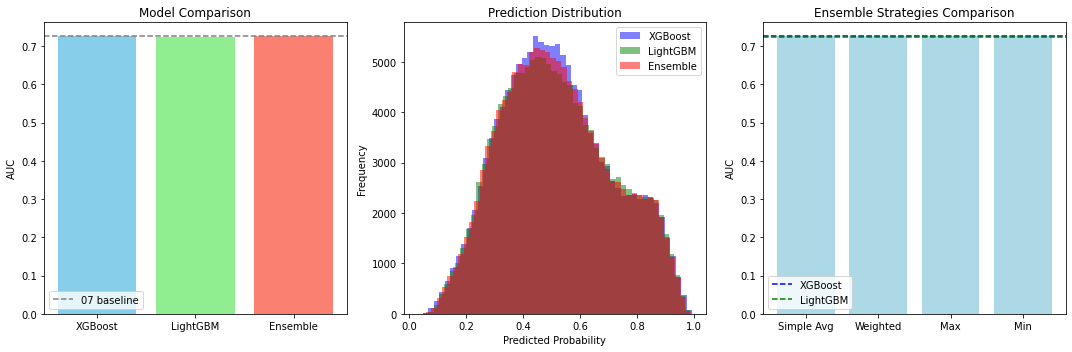


7. Generate Kaggle submission file...
Submission file saved to ../submissions/09_ensemble_xgb_lgb.csv


In [1]:
# 09_ensemble_xgb_lgb.ipynb
# Experiment: XGBoost + LightGBM model ensemble

import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, recall_score, f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("09_ensemble_xgb_lgb: XGBoost + LightGBM model ensemble") 
print("="*60)

# 1. Load data
print("\n1. Load data...") 
train = pd.read_csv('../data/train.csv')
print(f"Train shape: {train.shape}") 

# 2. Feature engineering function(reuse the best features from Experiment 08)
def create_selected_features(df):
    """Create the engineered features that proved useful earlier in the series.""" 
    df_new = df.copy()
    df_new['age_family_history'] = df['age'] * df['family_history_diabetes']
    df_new['age_bmi'] = df['age'] * df['bmi']
    df_new['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    df_new['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df_new['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    return df_new

# 3. Prepare data
print("\n2. Prepare data...") 
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

X_fe = create_selected_features(X)

# Feature selection
features_to_keep = [
    'age_family_history', 'age_bmi', 'cardio_risk_score',
    'cholesterol_ratio', 'non_hdl_cholesterol',
    'physical_activity_minutes_per_week', 'triglycerides', 'bmi',
    'ldl_cholesterol', 'cardiovascular_history', 'diet_score',
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'hdl_cholesterol',
    'cholesterol_total', 'waist_to_hip_ratio', 'sleep_hours_per_day',
    'screen_time_hours_per_day', 'alcohol_consumption_per_week',
    'hypertension_history', 'gender', 'ethnicity', 'education_level',
    'income_level', 'smoking_status', 'employment_status'
]

X_selected = X_fe[features_to_keep]

# Encode categorical features
categorical_cols = ['gender', 'ethnicity', 'education_level',
                   'income_level', 'smoking_status', 'employment_status']
X_encoded = pd.get_dummies(X_selected, columns=categorical_cols)
print(f"Total encoded feature count: {X_encoded.shape[1]}") 

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}") 

X_train_np = X_train.values.astype('float32')
X_val_np = X_val.values.astype('float32')
y_train_np = y_train.values.astype('int32')
y_val_np = y_val.values.astype('int32')

# 4. Load previously trained best models
print("\n3. Load previously trained best models...") 

# Best XGBoost model(from Experiment 07)
xgb_model = joblib.load('../models/08_xgboost_test_4_lr0.1.pkl')
print("✓ XGBoost model loaded successfully") 

# Best LightGBM model(from Experiment 08)
lgb_model = lgb.Booster(model_file='../models/08_lightgbm_test_1.txt')
print("✓ LightGBM model loaded successfully") 

# 5. Get predictions from both models
print("\n4. Get model predictions...") 

xgb_pred = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_pred)
print(f"XGBoost AUC: {xgb_auc:.4f}")

lgb_pred = lgb_model.predict(X_val_np)
lgb_auc = roc_auc_score(y_val, lgb_pred)
print(f"LightGBM AUC: {lgb_auc:.4f}")

# 6. Different ensemble strategies
print("\n5. Try different ensemble strategies...") 

ensemble_avg = (xgb_pred + lgb_pred) / 2
auc_avg = roc_auc_score(y_val, ensemble_avg)

weight_xgb = xgb_auc / (xgb_auc + lgb_auc)
weight_lgb = lgb_auc / (xgb_auc + lgb_auc)
ensemble_weighted = weight_xgb * xgb_pred + weight_lgb * lgb_pred
auc_weighted = roc_auc_score(y_val, ensemble_weighted)

ensemble_max = np.maximum(xgb_pred, lgb_pred)
auc_max = roc_auc_score(y_val, ensemble_max)

ensemble_min = np.minimum(xgb_pred, lgb_pred)
auc_min = roc_auc_score(y_val, ensemble_min)

print("\nEnsemble strategy results:") 
print("-" * 50)
print(f"{'Strategy':<20} {'AUC':<10} {'vs XGBoost':<15} {'vs LightGBM':<15}") 
print("-" * 50)
print(f"{'XGBoost only':<20} {xgb_auc:<10.4f} {'-':<15} {'-':<15}") 
print(f"{'LightGBM only':<20} {lgb_auc:<10.4f} {'-':<15} {'-':<15}") 
print(f"{'simple average':<20} {auc_avg:<10.4f} {auc_avg - xgb_auc:+.4f} {auc_avg - lgb_auc:+.4f}") 
print(f"{'weighted average':<20} {auc_weighted:<10.4f} {auc_weighted - xgb_auc:+.4f} {auc_weighted - lgb_auc:+.4f}") 
print(f"{'maximum':<20} {auc_max:<10.4f} {auc_max - xgb_auc:+.4f} {auc_max - lgb_auc:+.4f}") 
print(f"{'minimum':<20} {auc_min:<10.4f} {auc_min - xgb_auc:+.4f} {auc_min - lgb_auc:+.4f}") 
print("-" * 50)

best_auc = max(auc_avg, auc_weighted, auc_max, auc_min)
best_strategy = "simple average" 
if best_auc == auc_weighted:
    best_strategy = "weighted average" 
elif best_auc == auc_max:
    best_strategy = "maximum" 
elif best_auc == auc_min:
    best_strategy = "minimum" 

print(f"\nBest strategy: {best_strategy} (AUC={best_auc:.4f})") 

# 7. Run threshold analysis with the best ensemble strategy
print("\n6. Threshold optimization analysis(using the best ensemble strategy)...") 

if best_strategy == "simple average": 
    ensemble_best = ensemble_avg
elif best_strategy == "weighted average": 
    ensemble_best = ensemble_weighted
elif best_strategy == "maximum": 
    ensemble_best = ensemble_max
else:
    ensemble_best = ensemble_min

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
best_f1_avg = 0
best_threshold = 0.45

print("\nPerformance under different thresholds:") 
print("-" * 70)
print(f"{'Threshold':<8} {'Recall class 0':<10} {'Recall class 1':<10} {'gap':<8} {'F1_avg':<8}") 
print("-" * 70)

for thresh in thresholds:
    y_pred_thresh = (ensemble_best >= thresh).astype(int)
    r0 = recall_score(y_val, y_pred_thresh, pos_label=0)
    r1 = recall_score(y_val, y_pred_thresh, pos_label=1)
    f1_0 = f1_score(y_val, y_pred_thresh, pos_label=0)
    f1_1 = f1_score(y_val, y_pred_thresh, pos_label=1)
    f1_avg = (f1_0 + f1_1) / 2
    gap = r1 - r0
    print(f"{thresh:<8.2f} {r0:<10.3f} {r1:<10.3f} {gap:<8.3f} {f1_avg:<8.3f}")
    
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        best_threshold = thresh

print("-" * 70)
print(f"Best threshold: {best_threshold} (Mean F1={best_f1_avg:.3f})") 

# 8. Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
models = ['XGBoost', 'LightGBM', 'Ensemble']
aucs = [xgb_auc, lgb_auc, best_auc]
colors = ['skyblue', 'lightgreen', 'salmon']
plt.bar(models, aucs, color=colors)
plt.axhline(y=0.7251, color='gray', linestyle='--', label='07 baseline')
plt.ylabel('AUC')
plt.title('Model Comparison')
plt.legend()

# Prediction distribution comparison
plt.subplot(1, 3, 2)
plt.hist(xgb_pred, bins=50, alpha=0.5, label='XGBoost', color='blue')
plt.hist(lgb_pred, bins=50, alpha=0.5, label='LightGBM', color='green')
plt.hist(ensemble_best, bins=50, alpha=0.5, label='Ensemble', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Prediction Distribution')
plt.legend()

# Ensemble strategy comparison
plt.subplot(1, 3, 3)
strategies = ['Simple Avg', 'Weighted', 'Max', 'Min']
strategy_aucs = [auc_avg, auc_weighted, auc_max, auc_min]
plt.bar(strategies, strategy_aucs, color='lightblue')
plt.axhline(y=xgb_auc, color='blue', linestyle='--', label='XGBoost')
plt.axhline(y=lgb_auc, color='green', linestyle='--', label='LightGBM')
plt.ylabel('AUC')
plt.title('Ensemble Strategies Comparison')
plt.legend()

plt.tight_layout()
plt.savefig('../logs/09_ensemble_xgb_lgb_plots.png', dpi=100, bbox_inches='tight')
plt.show()

# 9. Generate submission file (using the best ensemble strategy)
print("\n7. Generate Kaggle submission file...") 

test = pd.read_csv('../data/test.csv')
X_test = test.drop(['id'], axis=1)
X_test_fe = create_selected_features(X_test)
X_test_selected = X_test_fe[features_to_keep]
X_test_encoded = pd.get_dummies(X_test_selected, columns=categorical_cols)

missing_cols = set(X_train.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train.columns]

X_test_np = X_test_encoded.values.astype('float32')

xgb_test_pred = xgb_model.predict_proba(X_test_encoded)[:, 1]
lgb_test_pred = lgb_model.predict(X_test_np)

if best_strategy == "simple average": 
    ensemble_test_pred = (xgb_test_pred + lgb_test_pred) / 2
elif best_strategy == "weighted average": 
    ensemble_test_pred = weight_xgb * xgb_test_pred + weight_lgb * lgb_test_pred
elif best_strategy == "maximum": 
    ensemble_test_pred = np.maximum(xgb_test_pred, lgb_test_pred)
else:
    ensemble_test_pred = np.minimum(xgb_test_pred, lgb_test_pred)

submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': ensemble_test_pred
})
submission_path = '../submissions/09_ensemble_xgb_lgb.csv'
submission.to_csv(submission_path, index=False)
print(f"Submission file saved to {submission_path}")


# Experiment 9 Summary: XGBoost + LightGBM Ensemble Checkpoint

## Role in the series
This notebook tests whether combining the strongest tree-based candidates can improve over the best single-model holdout result. Its role is not to declare a final ensemble strategy, but to check whether model combination is promising enough to justify further effort.

## Interpretation
The result is best interpreted cautiously. If the ensemble gain is small, the notebook still remains useful because it shows that validation design may matter more than an increasingly elaborate model stack. That insight helps motivate the later transition toward more careful evaluation choices.

## Position in the project story
This notebook closes the early holdout-based model search. The next major step is not another local tuning variation, but a broader rethink of how model quality should be validated and compared.
